# `bw_timex` — Background temporal distributions straight from **premise** (trails)

`premise`'s **trails** work ships a curated table of *background* temporal
data in `temporal_distributions.csv`: how long stock assets sit in use, when maintenance
happens, when end-of-life treatment kicks in, how biomass grows before harvest, etc. Each
row is placed onto matching exchanges by fixed rules.

`bw_timex` can mirror that curated data onto your **already-existing, year-specific premise
databases** in a single call:

```python
from bw_timex import add_premise_temporal_distributions
add_premise_temporal_distributions(["my_premise_db_2020", "my_premise_db_2030"])
```

This writes `bw_temporalis.TemporalDistribution` objects onto the matching background
exchanges. They are **ignored** by a normal run and by `traverse_background=False`, and only
take effect once you descend into the background with `traverse_background=True`.

> **Install note:** the annotation step needs premise's **trails** work, which is currently
> *unreleased*. Install bw_timex and premise together in a **Python 3.12** environment:
>
> ```
> pip install bw_timex "premise @ git+https://github.com/polca/premise.git@trails_temporal_distributions_update"
> ```
>
> Once the databases are annotated, running the `TimexLCA` itself does **not** need premise.

## Step 0 — Setup (same project as the premise EV / background examples)

We reuse the REMIND-EU project and the 2020 background variant referenced by the foreground.
Swap these names for your own premise databases if needed.

In [16]:
import bw2data as bd

bd.projects.set_current("ei312_REMIND_EU")

# Every prospective background variant the time-explicit run can route to. ALL of
# them must be annotated: with traverse_background=True the descent locks onto the
# variant a cohort routes to (e.g. the 2030 variant for a 2030 cohort) and reads
# deep background edges from *that* variant's data. If a variant carries no
# temporal distributions, cohorts routed through it are not time-shifted and the
# whole timeline collapses onto the start date.
BG_DATABASES = [
    "ei312_REMIND-EU_SSP2_NDC_2020",
    "ei312_REMIND-EU_SSP2_NDC_2030",
    "ei312_REMIND-EU_SSP2_NDC_2040",
]
BG_DATABASE = BG_DATABASES[0]  # the variant the foreground references

if "foreground" in bd.databases:
    del bd.databases["foreground"]  # rebuild the foreground from scratch
foreground = bd.Database("foreground")
foreground.register()

## Step 1 — Peek at what premise curates (optional)

Before annotating, we can load premise's temporal specs and look at the buckets they are
sorted into. This is exactly the data `add_premise_temporal_distributions` consumes —
inspecting it is optional but makes the next step less of a black box.

Each bucket is keyed by `(supplier name, reference product)`:

- **stock assets** — explicit temporal-parameter dicts (lifetime spread of long-lived goods)
- **maintenance** / **end-of-life** — suppliers whose TD is derived from the dataset lifetime
- **biomass growth** — CO₂-uptake-before-harvest curves on the `Carbon dioxide, in air` flow

In [17]:
from itertools import islice

try:
    from bw_timex.premise_temporal import load_temporal_specs

    specs = load_temporal_specs()
    print(f"stock asset suppliers : {len(specs.stock_asset_params)}")
    print(f"maintenance suppliers : {len(specs.maintenance_suppliers)}")
    print(f"end-of-life suppliers : {len(specs.end_of_life_suppliers)}")
    print(f"biomass growth params : {len(specs.biomass_growth_params)}")
    print(f"dataset lifetimes     : {len(specs.dataset_lifetimes)}")

    print("\nA few stock-asset entries (key -> premise temporal params):")
    for key, params in islice(specs.stock_asset_params.items(), 3):
        print("  ", key, "->", params)
except ImportError as err:
    print("premise is not importable, skipping the spec peek:")
    print(" ", err)

stock asset suppliers : 964
maintenance suppliers : 63
end-of-life suppliers : 170
biomass growth params : 429
dataset lifetimes     : 7160

A few stock-asset entries (key -> premise temporal params):
   ('air filter production, in exhaust air valve', 'air filter, in exhaust air valve') -> {'temporal_distribution': 5, 'temporal_loc': -1.2, 'temporal_scale': 1.0, 'temporal_offsets': None, 'temporal_weights': None, 'temporal_min': -2.0, 'temporal_max': -1.0, 'lifetime': 2.0, 'mean_age': None}
   ('ultraviolet lamp production, for water desinfection', 'ultraviolet lamp') -> {'temporal_distribution': 5, 'temporal_loc': -1.0, 'temporal_scale': 1.0, 'temporal_offsets': None, 'temporal_weights': None, 'temporal_min': -1.5, 'temporal_max': -1.0, 'lifetime': 1.5, 'mean_age': None}
   ('air filter production, central unit, 600 m3/h', 'air filter, central unit, 600 m3/h') -> {'temporal_distribution': 5, 'temporal_loc': -1.0, 'temporal_scale': 1.0, 'temporal_offsets': None, 'temporal_weights': Non

## Step 2 — Annotate the background databases

One call walks every exchange of each database, matches it against the premise rules, converts
the matching temporal params into `TemporalDistribution` objects, and saves them onto the
exchanges. It returns an `AnnotationReport`:

- `annotated` — exchanges that got a fresh TD
- `skipped_existing` — exchanges that already had a TD (re-run with `overwrite=True` to refresh)
- `faults` — rows it could not convert (it never aborts the pass on a single bad exchange)

**Annotate _every_ background variant in `database_dates`, not just the one the foreground
references.** With `traverse_background=True` the descent locks onto whichever variant a cohort
routes to and reads deep background edges from *that* variant. If only one variant is
annotated, cohorts routed through the others get no time shift and the timeline collapses onto
the start date.

In [18]:
from bw_timex import add_premise_temporal_distributions

report = add_premise_temporal_distributions(BG_DATABASES)

print("annotated        :", report.annotated)
print("skipped_existing :", report.skipped_existing)
print("faults           :", len(report.faults))
for fault in report.faults[:5]:
    print("   ", fault)

annotated        : 0
skipped_existing : 61098
faults           : 4581
    {'database': 'ei312_REMIND-EU_SSP2_NDC_2020', 'dataset': 'transport, passenger car, gasoline, Medium, EURO-2 | transport, passenger car, EURO-2', 'exchange': 'Passenger car, gasoline, Medium, EURO-2', 'reason': 'Temporal distribution conversion failed: Unsupported premise temporal_distribution code: 2'}
    {'database': 'ei312_REMIND-EU_SSP2_NDC_2020', 'dataset': 'transport, freight, lorry, compressed gas, 26 metric ton | transport, freight, lorry', 'exchange': 'lorry production, compressed gas, 26 metric ton', 'reason': 'Temporal distribution conversion failed: Unsupported premise temporal_distribution code: 2'}
    {'database': 'ei312_REMIND-EU_SSP2_NDC_2020', 'dataset': 'transport, freight, lorry, battery electric, 7.5 metric ton | transport, freight, lorry', 'exchange': 'lorry production, battery electric, 7.5 metric ton', 'reason': 'Temporal distribution conversion failed: Unsupported premise temporal_distri

## Step 3 — Inspect a few of the TDs that were written

The annotations now live on background exchanges. Let's pull a couple out and look at the
actual `TemporalDistribution` (the `date` offsets in years and their normalized `amount`
weights) so the curve premise curated is visible.

photovoltaic flat-roof installation, 156 kWp, multi-Si, on roof  ->  electricity production, photovoltaic, commercial
   date (years): [-30 -29 -28 -27 -26 -25 -24 -23 -22 -21 -20 -19 -18 -17 -16 -15 -14 -13
 -12 -11 -10  -9  -8  -7  -6  -5  -4  -3  -2  -1]
   amount      : [0.     0.0041 0.0081 0.0122 0.0162 0.0203 0.0243 0.0284 0.0325 0.0365
 0.0406 0.0446 0.0487 0.0527 0.0568 0.0609 0.0649 0.069  0.0632 0.0575
 0.0517 0.046  0.0402 0.0345 0.0287 0.023  0.0172 0.0115 0.0057 0.    ]

photovoltaic flat-roof installation, 156 kWp, single-Si, on roof  ->  electricity production, photovoltaic, commercial
   date (years): [-30 -29 -28 -27 -26 -25 -24 -23 -22 -21 -20 -19 -18 -17 -16 -15 -14 -13
 -12 -11 -10  -9  -8  -7  -6  -5  -4  -3  -2  -1]
   amount      : [0.     0.0041 0.0081 0.0122 0.0162 0.0203 0.0243 0.0284 0.0325 0.0365
 0.0406 0.0446 0.0487 0.0527 0.0568 0.0609 0.0649 0.069  0.0632 0.0575
 0.0517 0.046  0.0402 0.0345 0.0287 0.023  0.0172 0.0115 0.0057 0.    ]

photovoltaic open g

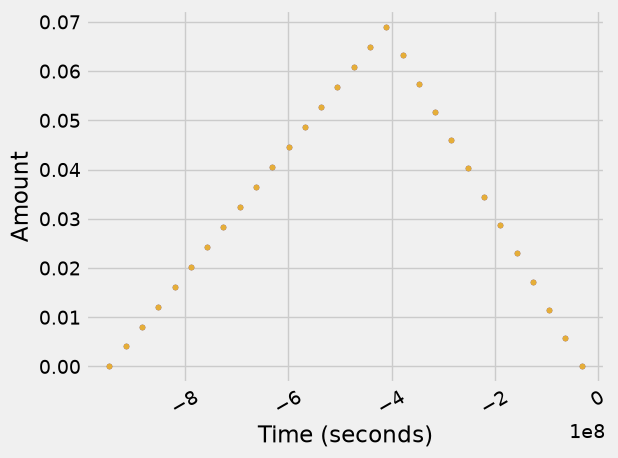

In [19]:
annotated_exchanges = []
for ds in bd.Database(BG_DATABASE):
    for exc in ds.technosphere():
        if exc.get("temporal_distribution") is not None:
            annotated_exchanges.append(exc)
    if len(annotated_exchanges) >= 3:
        break

for exc in annotated_exchanges[:3]:
    td = exc["temporal_distribution"]
    td.graph()
    print(f"{exc.input['name']}  ->  {exc.output['name']}")
    print("   date (years):", td.date.astype('timedelta64[Y]').astype(int))
    print("   amount      :", td.amount.round(4))
    print()

## Step 4 — A tiny foreground that consumes a background process

We build a one-process foreground `A` that demands an electric passenger car production from
the background. Its upstream chain (glider, maintenance, end-of-life, …) contains exchanges we
just annotated, so descending into the background will time-shift those flows.

In [20]:
P1 = bd.get_node(
    database=BG_DATABASE,
    name="passenger car production, electric, without battery",
)
print("P1:", P1["name"], "|", P1.get("location"), "|", P1["code"])

A = foreground.new_node("A", name="process A", unit="unit")
A["reference product"] = "A"
A.save()

A.new_edge(input=A, amount=1, type="production").save()
A.new_edge(input=P1, amount=1, type="technosphere").save()
print("Foreground A -> P1 created.")

P1: passenger car production, electric, without battery | GLO | 24511137e9da4c9ebb5f39d4caea0705
Foreground A -> P1 created.


## Step 5 — `TimexLCA` with `traverse_background=True`

`traverse_background=True` is what makes the engine descend into the background and pick up the
premise trails TDs we just wrote. We use `graph_traversal="bfs"` (recommended with background
traversal) and start in 2030 so the time-shifts land between the 2020/2030 database variants.

In [21]:
from datetime import datetime

method = (
    "ecoinvent-3.12",
    "EF v3.1",
    "climate change",
    "global warming potential (GWP100)",
)

database_dates = {
    "ei312_REMIND-EU_SSP2_NDC_2020": datetime.strptime("2020", "%Y"),
    "ei312_REMIND-EU_SSP2_NDC_2030": datetime.strptime("2030", "%Y"),
    "ei312_REMIND-EU_SSP2_NDC_2040": datetime.strptime("2040", "%Y"),
    "foreground": "dynamic",
}

In [22]:
from bw_timex import TimexLCA

# Building the TimexLCA runs a full static ecoinvent LCA of the demand under the
# hood (the "base LCA"), which is the slowest step here (~30 s on a cold cache).
tlca = TimexLCA({A: 1}, method, database_dates)

2026-06-29 17:00:21.912 | INFO     | bw_timex.timex_lca:__init__:136 - Initializing TimexLCA object...
2026-06-29 17:00:21.913 | INFO     | bw_timex.timex_lca:__init__:153 - Calculating base LCA...
2026-06-29 17:00:34.983 | INFO     | bw_timex.timex_lca:__init__:170 - Collecting node infos...


## Step 6 — Compute the score and confirm the trails TDs move emissions in time

We compute the time-explicit score with background traversal on, then compare against
`traverse_background=False` (which ignores every background TD, treating the background as a
static snapshot). A difference between the two scores is the premise trails data taking effect.

In [29]:
tlca.build_timeline(
    starting_datetime="2030-01-01",
    temporal_grouping="year",
    graph_traversal="priority",
    traverse_background=True,
    max_calc=1000,
)

2026-06-30 09:10:42.128 | WARNING  | bw_timex.timex_lca:build_timeline:309 - traverse_background=True with graph_traversal='priority': non-referenced background variants are not placed on the priority heap; each variant subtree is walked in full via proxy reads when its parent edge is reached. The referenced-system heap exploration order is unchanged and explored amounts are exact (identical to graph_traversal='bfs' for these subtrees).
2026-06-30 09:10:42.131 | INFO     | bw_timex.timex_lca:build_timeline:363 - Creating activity time mapping...
2026-06-30 09:10:43.376 | INFO     | bw_timex.timeline_builder:__init__:112 - Traversing supply chain graph...


Starting graph traversal


/Users/timodiepers/Documents/Coding/bw_timex/.venv/lib/python3.12/site-packages/bw_graph_tools/graph_traversal/new_node_each_visit.py:373: UserWarning: Stopping traversal due to calculation count.
  warnings.warn("Stopping traversal due to calculation count.")
/Users/timodiepers/Documents/Coding/bw_timex/.venv/lib/python3.12/site-packages/bw_graph_tools/graph_traversal/new_node_each_visit.py:351: UserWarning: Graph traversal covered only 20.9% of the total LCA score. Consider lowering the `cutoff` (currently 1e-09) to improve coverage.
  warnings.warn(


Calculation count: 1008


2026-06-30 09:27:32.713 | INFO     | bw_timex.timeline_builder:build_timeline:186 - Building timeline...
2026-06-30 09:27:33.201 | INFO     | bw_timex.timeline_builder:get_weights_for_interpolation_between_nearest_years:623 - Reference date 1881-01-01 00:00:00 is lower than all provided dates. Data will be taken from the closest higher year.
2026-06-30 09:27:33.204 | INFO     | bw_timex.timeline_builder:get_weights_for_interpolation_between_nearest_years:630 - Reference date 2041-01-01 00:00:00 is higher than all provided dates. Data will be taken from the closest lower year.


,date_producer,producer_name,date_consumer,consumer_name,amount,temporal_market_shares
0,1881-01-01,"hydropower plant construction, reservoir, alpi...",2030-01-01,"electricity production, hydro, reservoir, alpi...",0.0,None
1,1881-01-01,"hydropower plant construction, reservoir, alpi...",2030-01-01,"electricity production, hydro, reservoir, alpi...",0.0,None
2,1881-01-01,"hydropower plant construction, reservoir, non-...",2030-01-01,"electricity production, hydro, reservoir, non-...",0.0,None
3,1882-01-01,"hydropower plant construction, reservoir, alpi...",2030-01-01,"electricity production, hydro, reservoir, alpi...",0.0,None
4,1882-01-01,"hydropower plant construction, reservoir, alpi...",2030-01-01,"electricity production, hydro, reservoir, alpi...",0.0,None
...,...,...,...,...,...,...
6473,2068-01-01,"recultivation, limestone mine",2030-01-01,limestone quarry operation,0.0,None
6474,2069-01-01,"recultivation, limestone mine",2030-01-01,gravel and sand quarry operation,0.0,None
6475,2069-01-01,"recultivation, limestone mine",2030-01-01,limestone quarry operation,0.0,None
6476,2070-01-01,"recultivation, limestone mine",2030-01-01,gravel and sand quarry operation,0.0,None


In [30]:
tlca.lci()
tlca.static_lcia()

2026-06-30 09:27:43.002 | INFO     | bw_timex.timex_lca:lci:513 - Expanding matrices...
2026-06-30 09:28:07.251 | INFO     | bw_timex.timex_lca:lci:532 - Calculating dynamic inventory...


In [31]:
tlca.base_lca.score

6.89061727369748

In [32]:
tlca.static_score

4.953254842324384

In [35]:
from bw_timex.utils import plot_characterized_inventory_as_waterfall

In [37]:
tlca.dynamic_lcia(metric="GWP")

2026-06-30 09:33:52.123 | INFO     | dynamic_characterization.dynamic_characterization:characterize:126 - No custom dynamic characterization functions provided. Using default dynamic             characterization functions. The flows that are characterized are based on the selection                of the initially chosen impact category.


,date,amount,flow,activity
0,1991-01-01,2.502334e-11,267655084047331383,329999541917872830
1,1991-01-01,3.910796e-09,267655084047331383,329999541917872831
2,1991-01-01,2.297956e-07,267655084047331383,329999541917872842
3,1992-01-01,5.004668e-11,267655084047331383,329999541917872857
4,1992-01-01,7.821593e-09,267655084047331383,329999541917872858
...,...,...,...,...
2106,2030-01-01,4.897550e-04,267655084861026358,267663074611687428
2107,2030-01-01,6.897742e-04,267655084890386433,267662799448567809
2108,2030-01-01,7.426431e-04,267655083426574370,267662795002605568
2109,2030-01-01,8.196849e-04,267655084861026358,267663074632658950


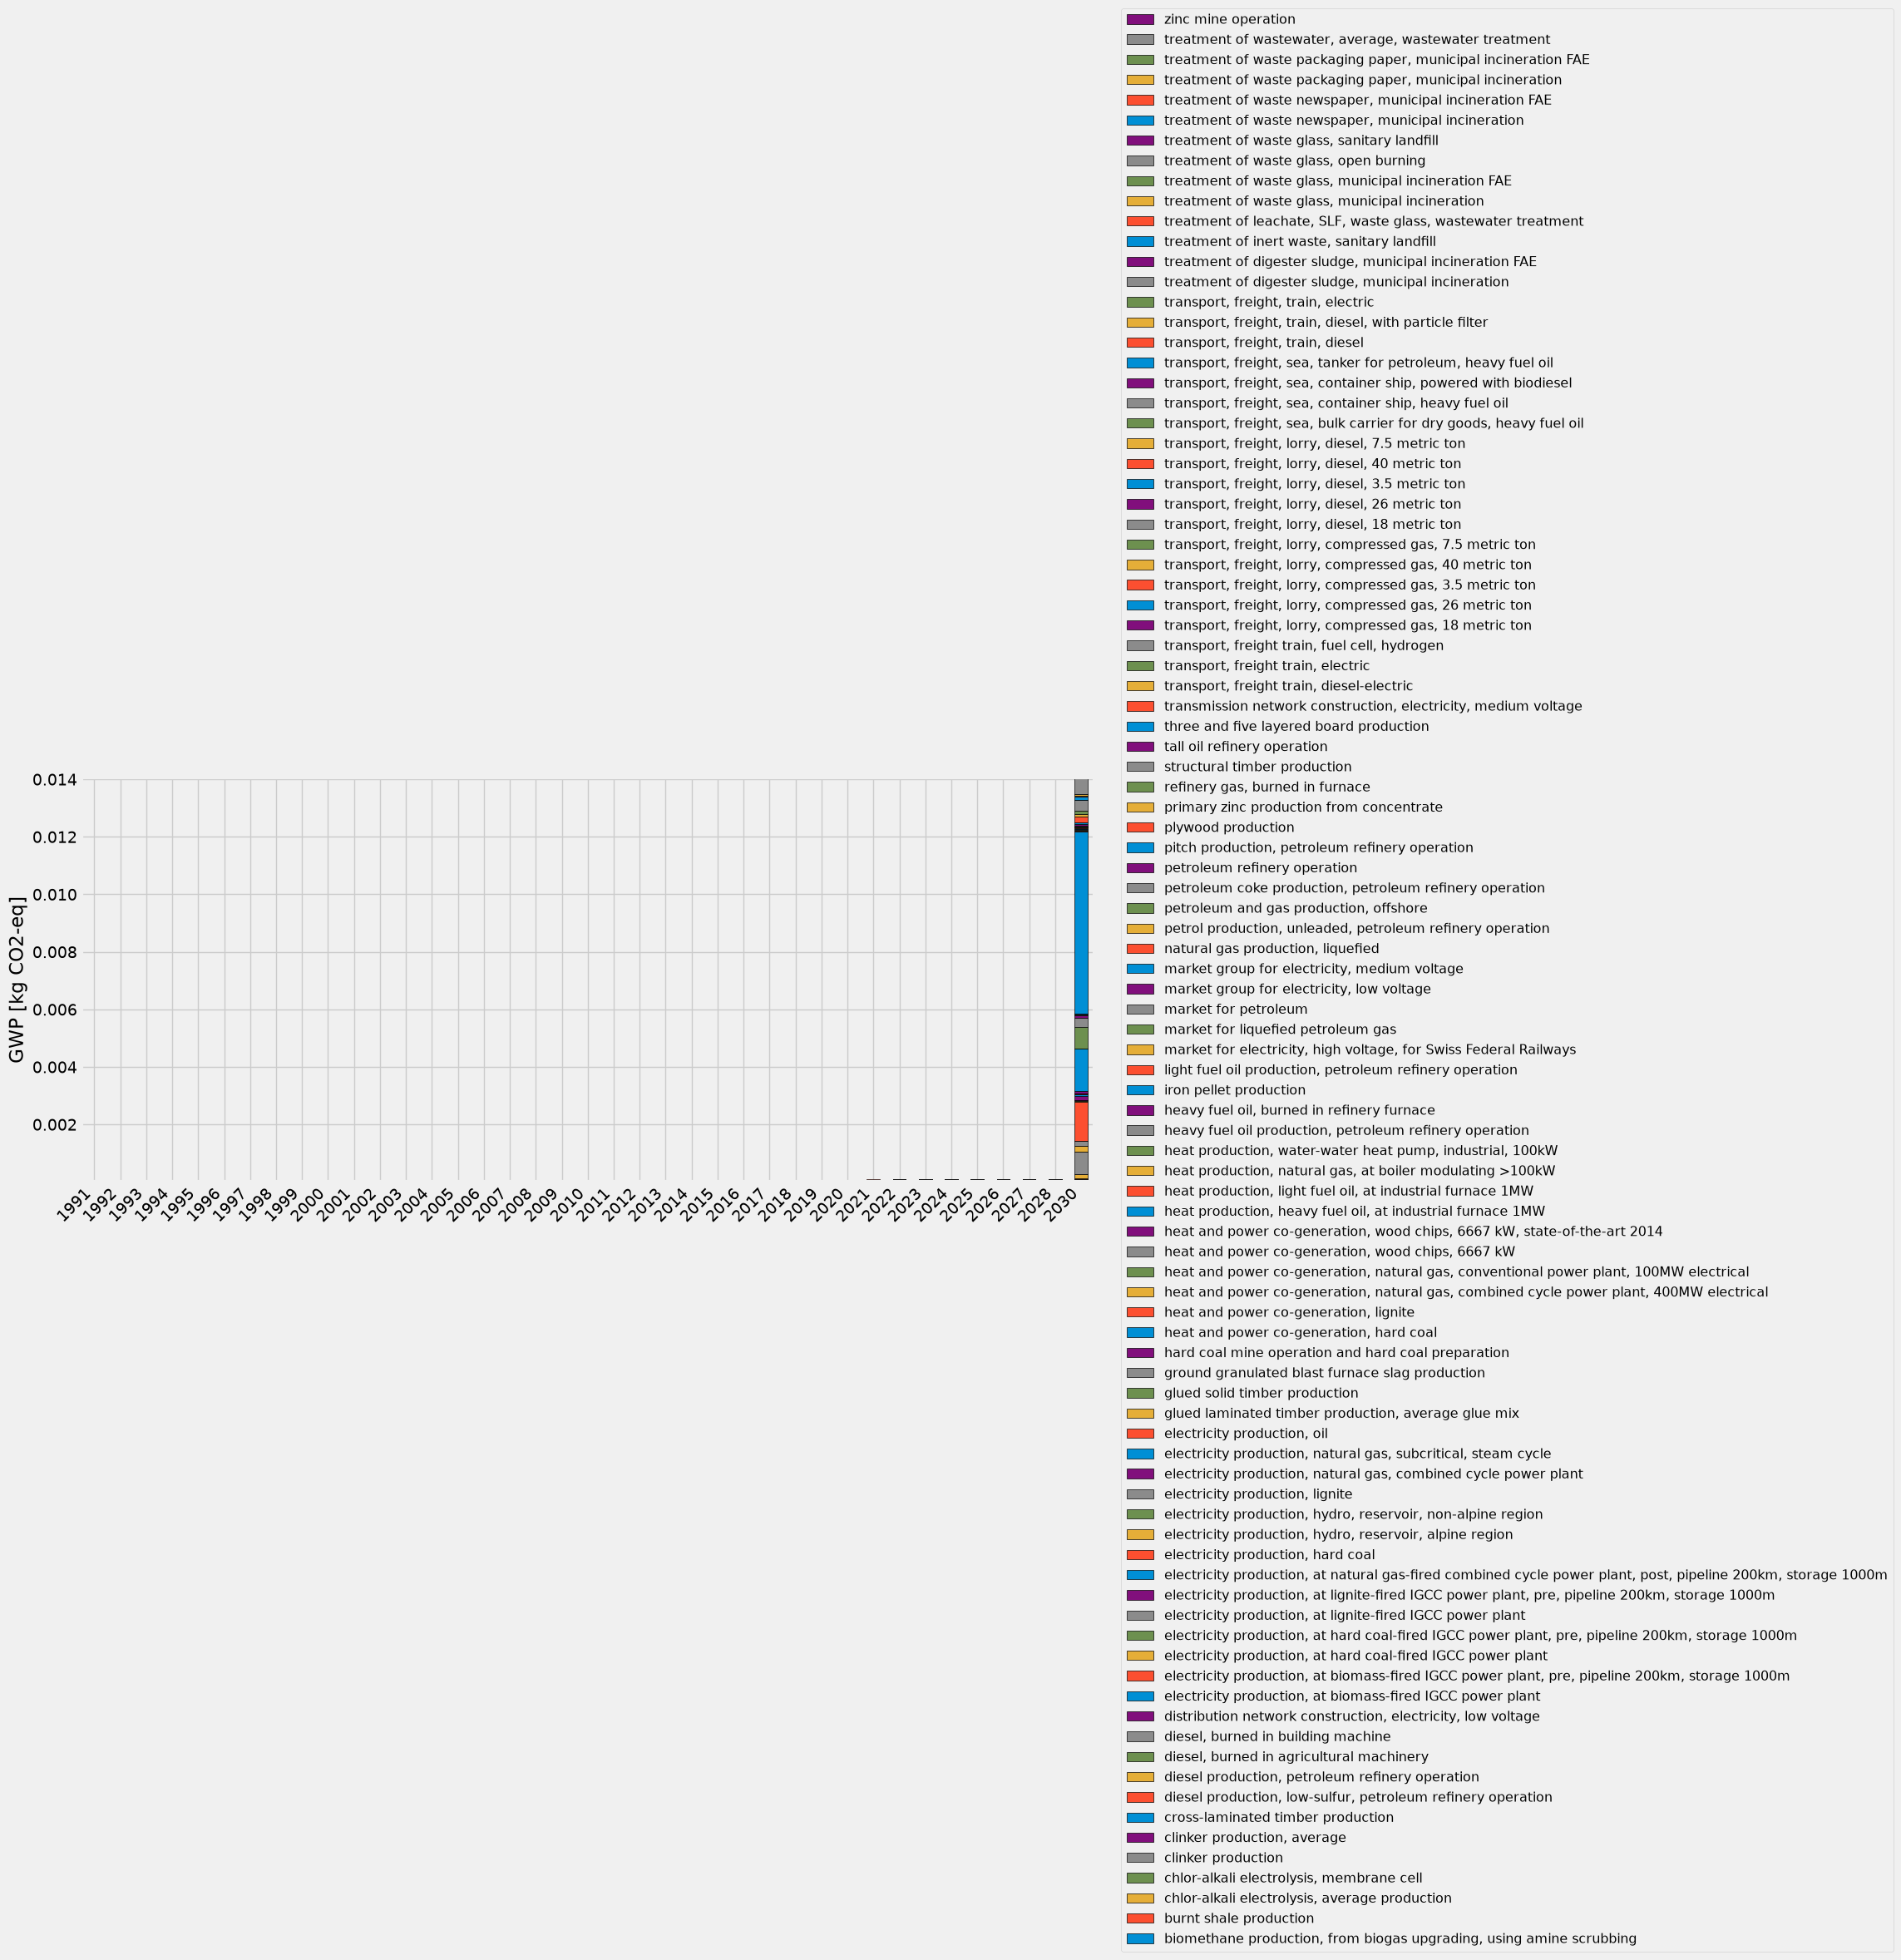

In [38]:
plot_characterized_inventory_as_waterfall(tlca)

## Notes on persistence

The temporal distributions written by `add_premise_temporal_distributions` are **persisted
inside the premise background databases**. That means:

- You only need to annotate once; the TDs stay until you change them.
- They are inert for any normal LCA and for `traverse_background=False`, so leaving them in
  place is harmless — we deliberately do **not** strip them here.
- Re-running `add_premise_temporal_distributions([...])` skips exchanges that already have a
  TD (see `report.skipped_existing`). To refresh them after a premise/trails update, pass
  `overwrite=True`.

```python
add_premise_temporal_distributions(BG_DATABASES, overwrite=True)
```